# ee2026 sprite generator

Our ee2026 final project utilised some labor intensive methods aided by some crude c++ and python code to generate sprites.
Hence I have set out on a project to create a python program that is able to automate the creation of an entire sprite module from an image/gif.
This notebook documents my development process.

## Final Image to Sprite Generator 

this is the final image generator. it opens the image specified in imfile and generates verilog module as a .v file. For the code detials and the development process refer to the other code blocks below ...

colors = 3
original


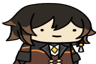

0 - median cut:


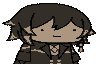

1 - maximum coverage


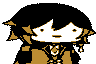

2 - median cut, kmeans:


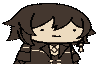

3 - maximum coverage, kmeans


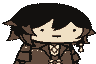

output:


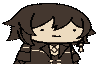

complete


In [12]:
#change the image file name here
imfile = "zhong.png"

#change the output file name here
filename = "zhong"

#change the module name here
modulename = "zhongli"

#change the size of the output sprite here
sprite_width = 96
sprite_height = 64

from PIL import Image
import numpy as np
from IPython.display import display
ccount = int(input("select maximum number of colors"))


imo = Image.open(imfile).convert("RGBA")
imo = imo.resize((sprite_width, sprite_height))
al = imo.getchannel("A").convert('1').convert('L')
im = imo.convert("RGB")

r0,g0,b0 = im.quantize(ccount, method = 0, kmeans = 0).convert("RGB").split()
r1,g1,b1 = im.quantize(ccount, method = 1, kmeans = 0).convert("RGB").split()
r2,g2,b2 = im.quantize(ccount, method = 0, kmeans = 1).convert("RGB").split()
r3,g3,b3 = im.quantize(ccount, method = 1, kmeans = 1).convert("RGB").split()

iml = (Image.merge("RGBA",(r0,g0,b0,al)),Image.merge("RGBA",(r1,g1,b1,al)),Image.merge("RGBA",(r2,g2,b2,al)),Image.merge("RGBA",(r3,g3,b3,al)))
print(f"colors = {ccount}")
print("original")
display(imo)
print("0 - median cut:")
display(iml[0])
print("1 - maximum coverage")
display(iml[1])
print("2 - median cut, kmeans:")
display(iml[2])
print("3 - maximum coverage, kmeans")
display(iml[3])

x = -1
while not x in range(0,4) : 
    x = int(input("select quantization mode"))

print("output:")
display(iml[x])

img = np.array(iml[x])
r,b,g,a = np.split(img,img.shape[2],axis=2)
r=r.reshape(-1)
g=g.reshape(-1)
b=b.reshape(-1)
a=a.reshape(-1)

data = dict()
for i in range(len(r)):
    color = 0 if a[i] == 0 else str(bin(int(r[i]/255*31))[2:].zfill(5)+bin(int(b[i]/255*63))[2:].zfill(6)+bin(int(g[i]/255*31))[2:].zfill(5))
    data.setdefault(color, []).append(i)

sprite = [[f"assign shape{j}[{i}] = {img.shape[1]}'b"+''.zfill(img.shape[1])+';' for i in range(img.shape[0])] for j in range(len(bin(len(data)-1)[2:]))]

t = "    "

file = open(f"{filename}.v","w")

file.write("/*\n * This file is generated by a python script. \n * image quantization is done by PIL library. \n * image quantisation mode:{x} \n * number of colors: {ccount} \n * module name: {modulename} \n */\n\n".format(x = x, ccount = ccount, modulename = modulename))
file.write("`timescale 1ns / 1ps \n\n")
file.write(f"module {modulename}(CLOCK,x,y,xshift,yshift,col_index, alpha);\n\n")
file.write(f"{t}input CLOCK; \n{t}input [6:0]x,y,xshift,yshift; \n{t}output reg alpha = 1; \n{t}output reg [15:0] col_index \n\n")

for i in range(len(bin(len(data)-1)[2:])):
    file.write(t+f"wire [{img.shape[1]-1}:0]shape{i}[{img.shape[0]-1}:0]"+"\n")

file.write("\n")

for i in range(len(sprite)): 
    for j in sprite[i]:
        file.write(t + j + "\n")

file.write("\n")

file.write(t+"always @(*) begin \n")

el = False
for i,col in enumerate(data):
    if col:
        if el:
            file.write(t+t+"else if(")
        else:
            file.write(t+t+"if (") 
            el = True 
        for k in range(len(bin(len(data)-1)[2:])):
            if int(bin(i)[2:].zfill(len(bin(len(data)-1)[2:]))[k]):
                file.write(f"shape{k}[y - yshift][x - xshift] && ")
            else:
                file.write(f"!shape{k}[y - yshift][x - xshift] && ")
        file.seek(0, 2)
        file.seek(file.tell() - 4, 0)
        file.truncate()
        file.write(") begin \n" + t+t+t + "alpha = 1;\n" + t+t+t+ f"col_index = 16'b{col};\n" + t+t +"end\n")
file.write(t+t+"else alpha = 0;\n ")
file.write(t+"end\n")

file.write("\n endmodule")

file.close()
print("complete")


 ## Development

First things first, libraries.

Keeping things as simple as possible, this project only requires pil and numpy.  
to display a preview of what the image looks like in the notebook, ipython display is imported as well(this will be apparent why later on)

In [1]:
from PIL import Image
import numpy as np
from IPython.display import display

i started out by testing out the pil library
numpy arrays make processing the image data really easy, and i was apply to resize the test image and map each pixel to its repective color in no time.

In [2]:
from PIL import Image
import numpy as np
img = Image.open('zhong.png')
img = img.resize((40,40))
img = np.array(img)
r,b,g,a = np.split(img,img.shape[2],axis=2)
r=r.reshape(-1)
g=r.reshape(-1)
b=r.reshape(-1)
a=a.reshape(-1)
for i in range(len(r)):
     print("if (pixel_index == ",i,") oled_data = 16'b",bin(int(r[i]/256*32))[2:].zfill(5),bin(int(b[i]/256*64))[2:].zfill(6),bin(int(g[i]/256*32))[2:].zfill(5),';',sep = '')

if (pixel_index == 0) oled_data = 16'b0000000000000000;
if (pixel_index == 1) oled_data = 16'b0000000000000000;
if (pixel_index == 2) oled_data = 16'b0000000000000000;
if (pixel_index == 3) oled_data = 16'b0000000000000000;
if (pixel_index == 4) oled_data = 16'b0000000000000000;
if (pixel_index == 5) oled_data = 16'b0000000000000000;
if (pixel_index == 6) oled_data = 16'b0000000000000000;
if (pixel_index == 7) oled_data = 16'b0000000000000000;
if (pixel_index == 8) oled_data = 16'b0000000000000000;
if (pixel_index == 9) oled_data = 16'b0000000000000000;
if (pixel_index == 10) oled_data = 16'b0000000000000000;
if (pixel_index == 11) oled_data = 16'b0000000000000000;
if (pixel_index == 12) oled_data = 16'b0000000000000000;
if (pixel_index == 13) oled_data = 16'b0000000000000000;
if (pixel_index == 14) oled_data = 16'b0000000000000000;
if (pixel_index == 15) oled_data = 16'b0000000000000000;
if (pixel_index == 16) oled_data = 16'b0000000000000000;
if (pixel_index == 17) oled_data = 16'b00

I then experimented in the the quantization modes in PIL, resulting in the compiled code that converts the image into a basic verilog syntax

colors = 5
original


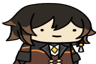

0 - median cut:


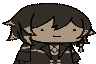

1 - maximum coverage


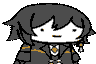

2 - median cut, kmeans:


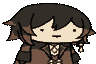

3 - maximum coverage, kmeans


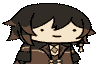

output:


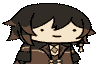

if(pixel_index == 325||(pixel_index >= 327 && pixel_index <=345)||pixel_index == 347||(pixel_index >= 415 && pixel_index <=422)||(pixel_index >= 442 && pixel_index <=448)||(pixel_index >= 507 && pixel_index <=511)||(pixel_index >= 545 && pixel_index <=548)||(pixel_index >= 601 && pixel_index <=603)||(pixel_index >= 644 && pixel_index <=647)||(pixel_index >= 695 && pixel_index <=696)||(pixel_index >= 743 && pixel_index <=745)||(pixel_index >= 789 && pixel_index <=791)||(pixel_index >= 842 && pixel_index <=844)||(pixel_index >= 884 && pixel_index <=885)||(pixel_index >= 940 && pixel_index <=941)||(pixel_index >= 979 && pixel_index <=980)||(pixel_index >= 1038 && pixel_index <=1039)||(pixel_index >= 1074 && pixel_index <=1075)||(pixel_index >= 1135 && pixel_index <=1136)||(pixel_index >= 1169 && pixel_index <=1170)||(pixel_index >= 1233 && pixel_index <=1234)||(pixel_index >= 1264 && pixel_index <=1265)||(pixel_index >= 1281 && pixel_index <=1282)||(pixel_index >= 1330 && pixel_index <=13

In [3]:
from PIL import Image
import numpy as np
from IPython.display import display
ccount = int(input("select maximum number of colors"))
#change the image file name here
imfile = "zhong.png"

imo = Image.open(imfile).convert("RGBA")
imo = imo.resize((96,64))
al = imo.getchannel("A").convert('1').convert('L')
im = imo.convert("RGB")

r0,g0,b0 = im.quantize(ccount, method = 0, kmeans = 0).convert("RGB").split()
r1,g1,b1 = im.quantize(ccount, method = 1, kmeans = 0).convert("RGB").split()
r2,g2,b2 = im.quantize(ccount, method = 0, kmeans = 1).convert("RGB").split()
r3,g3,b3 = im.quantize(ccount, method = 1, kmeans = 1).convert("RGB").split()

iml = (Image.merge("RGBA",(r0,g0,b0,al)),Image.merge("RGBA",(r1,g1,b1,al)),Image.merge("RGBA",(r2,g2,b2,al)),Image.merge("RGBA",(r3,g3,b3,al)))
print(f"colors = {ccount}")
print("original")
display(imo)
print("0 - median cut:")
display(iml[0])
print("1 - maximum coverage")
display(iml[1])
print("2 - median cut, kmeans:")
display(iml[2])
print("3 - maximum coverage, kmeans")
display(iml[3])

x = -1
while not x in range(0,4) : 
    x = int(input("select quantization mode"))

print("output:")
display(iml[x])

img = np.array(iml[x])
r,b,g,a = np.split(img,img.shape[2],axis=2)
r=r.reshape(-1)
g=g.reshape(-1)
b=b.reshape(-1)
a=a.reshape(-1)

data = dict()
for i in range(len(r)):
    color = 0 if a[i] == 0 else str(bin(int(r[i]/255*31))[2:].zfill(5)+bin(int(b[i]/255*63))[2:].zfill(6)+bin(int(g[i]/255*31))[2:].zfill(5))
    data.setdefault(color, []).append(i)
# print (data)

# for i in data:
#     if(i):
#         string = "if(" if i == '0000000000000000' else "else if()"
#         for j in data[i]:
#             string += "pixel_index == "+str(j)+"||"
#         print(f"{string[:-2]}) oled_data = 16'b{i};")

el = False
for i,col in enumerate(data):
    if(col):
        state = False
        if el:
            string = "else if("
        else:
            string = "if(" 
            el = True
        for j, pix in enumerate(data[col]):
            if pix != data[col][-1] and data[col][j+1] == pix + 1:
                if not state: 
                    string += "(pixel_index >= "+str(pix)
                state = True
            elif state:
                string += " && pixel_index <=" + str(pix) + ")||"
                state = False
            else: string += "pixel_index == " + str(pix) + "||"

        print(f"{string[:-2]}) oled_data = 16'b{col};")

Code block to test generating color values in verilog format


In [4]:
# for i in data:
#     if(i):
#         string = "if(" if i == '0000000000000000' else "else if()"
#         for j in data[i]:
#             string += "pixel_index == "+str(j)+"||"
#         print(f"{string[:-2]}) oled_data = 16'b{i};")


for i,col in enumerate(data):
    if(col):
        state = False
        string = "if(" if not i-1 else "else if()"
        for j, pix in enumerate(data[col]):
            if pix != data[col][-1] and data[col][j+1] == pix + 1:
                if not state: 
                    string += "(pixel_index >= "+str(pix)
                state = True
            elif state:
                string += " && pixel_index <=" + str(pix) + ")||"
                state = False
            else: string += "pixel_index == " + str(pix) + "||"

        print(f"{string[:-2]}) oled_data = 16'b{col};")

if(pixel_index == 325||(pixel_index >= 327 && pixel_index <=345)||pixel_index == 347||(pixel_index >= 415 && pixel_index <=422)||(pixel_index >= 442 && pixel_index <=448)||(pixel_index >= 507 && pixel_index <=511)||(pixel_index >= 545 && pixel_index <=548)||(pixel_index >= 601 && pixel_index <=603)||(pixel_index >= 644 && pixel_index <=647)||(pixel_index >= 695 && pixel_index <=696)||(pixel_index >= 743 && pixel_index <=745)||(pixel_index >= 789 && pixel_index <=791)||(pixel_index >= 842 && pixel_index <=844)||(pixel_index >= 884 && pixel_index <=885)||(pixel_index >= 940 && pixel_index <=941)||(pixel_index >= 979 && pixel_index <=980)||(pixel_index >= 1038 && pixel_index <=1039)||(pixel_index >= 1074 && pixel_index <=1075)||(pixel_index >= 1135 && pixel_index <=1136)||(pixel_index >= 1169 && pixel_index <=1170)||(pixel_index >= 1233 && pixel_index <=1234)||(pixel_index >= 1264 && pixel_index <=1265)||(pixel_index >= 1281 && pixel_index <=1282)||(pixel_index >= 1330 && pixel_index <=13

code block to test formatting the image 

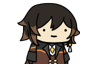

In [5]:
image = Image.open("zhong.png") 

image = image.resize((64,64))
  
width, height = image.size
  
result = Image.new(image.mode, (96, 64), (0, 0, 0, 0)) 
  
result.paste(image, (int((96-width)/2), int((64-height)/2))) 
  
display(result)

Finally, I experimented with generating a verilog bitmap, which is the format i used for my ee2026 project as it is way more versatile (I could easily translate the bitmap in the xy coordinate)

In [6]:
for i in range(len(bin(len(data)-1)[2:])):
    print(f"wire [{img.shape[1]-1}:0]shape{i}[{img.shape[0]-1}:0]")
    
sprite = [[f"assign shape{j}[{i}] = {img.shape[1]}'b"+''.zfill(img.shape[1])+';' for i in range(img.shape[0])] for j in range(len(bin(len(data)-1)[2:]))]

for i,col in enumerate(data):
    if(col):
        for j in data[col]:
            for k in range(len(bin(len(data)-1)[2:])):
                if int(bin(i)[2:].zfill(len(bin(len(data)-1)[2:]))[k]):
                    sprite[k][int(j/img.shape[1])] = sprite[k][int(j/img.shape[1])][:-1-img.shape[1]+j%img.shape[1]] + '1' + sprite[k][int(j/img.shape[1])][-img.shape[1]+j%img.shape[1]:]

for i in range(len(sprite)): 
    for j in sprite[i]:
        print(j)

for i,col in enumerate(data):
    print(bin(i)[2:].zfill(len(bin(len(data)-1)[2:])),":",col)

wire [95:0]shape0[63:0]
wire [95:0]shape1[63:0]
wire [95:0]shape2[63:0]
assign shape0[0] = 96'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000;
assign shape0[1] = 96'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000;
assign shape0[2] = 96'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000;
assign shape0[3] = 96'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000;
assign shape0[4] = 96'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000;
assign shape0[5] = 96'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000;
assign shape0[6] = 96'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000;
assign shape0[7] = 96'b0000000000000000000000000000000000000000000000000000000000

Finally, this block of code generates a complete sprite verilog module in a .v file 

In [7]:
t = "    "

filename = "zhong1"

file = open(f"{filename}.v","w")

file.write("`timescale 1ns / 1ps \n\n")
file.write(f"module {filename}(CLOCK,x,y,xshift,yshift,col_index, alpha);\n\n")
file.write(f"{t}input CLOCK; \n{t}input [6:0]x,y,xshift,yshift; \n{t}output reg alpha = 1; \n{t}output reg [15:0] col_index \n\n")

for i in range(len(bin(len(data)-1)[2:])):
    file.write(t+f"wire [{img.shape[1]-1}:0]shape{i}[{img.shape[0]-1}:0]"+"\n")

file.write("\n")

for i in range(len(sprite)): 
    for j in sprite[i]:
        file.write(t + j + "\n")

file.write("\n")

file.write(t+"always @(*) begin \n")

el = False
for i,col in enumerate(data):
    if col:
        if el:
            file.write(t+t+"else if(")
        else:
            file.write(t+t+"if (") 
            el = True 
        for k in range(len(bin(len(data)-1)[2:])):
            if int(bin(i)[2:].zfill(len(bin(len(data)-1)[2:]))[k]):
                file.write(f"shape{k}[y - yshift][x - xshift] && ")
            else:
                file.write(f"!shape{k}[y - yshift][x - xshift] && ")
        file.seek(0, 2)
        file.seek(file.tell() - 4, 0)
        file.truncate()
        file.write(") begin \n" + t+t+t + "alpha = 1;\n" + t+t+t+ f"col_index = 16'b{col};\n" + t+t +"end\n")
file.write(t+t+"else alpha = 0;\n ")
file.write(t+"end\n")

file.write("\n endmodule")

file.close()
print("complete")


complete


of course, I had to try doing this for animated sprites, and of course i had to use a gif of bad apple (not tested)

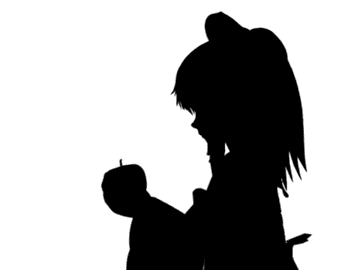

3110
50 ms


In [8]:
gif = Image.open("badapple.gif")
gif.seek(0)
display(gif)
print(gif.n_frames)
print (gif.info['duration'],"ms")

In [ ]:
# quantization mode
x = 0
# number of colors
ccount = 4

In [10]:
t = "    "

filename = "badapple"
gifname = "BadApple"

file = open(f"{filename}.v","w")

file.write("`timescale 1ns / 1ps \n\n")
file.write(f"module {filename}(CLOCK,x,y,xshift,yshift,col_index, alpha);\n\n")
file.write(f"{t}input CLOCK; \n{t}input [6:0]x,y,xshift,yshift; \n{t}output reg alpha = 1; \n{t}output reg [15:0] col_index \n\n")

gif = Image.open(f"{gifname}.gif")

file.write(f"{t}reg [{len(bin(gif.n_frames)[2:])}:0]count = 0; \n{t}always @(posedge CLOCK) count = count == 100000*{gif.info['duration']} ? 0: count + 1; \n")

datakey = list()    

for frame in range(gif.n_frames):
    gif.seek(frame)

    imo = gif.convert("RGBA")
    imo = imo.resize((64,64))#w,h
    a = imo.getchannel("A").convert('1').convert('L')
    im = imo.convert("RGB")

    r,g,b = im.quantize(ccount, method = 0 if x == 0 or x == 2 else 1, kmeans = 0 if x == 0 or x == 1 else 1).convert("RGB").split()

    r=np.array(r).reshape(-1)
    g=np.array(g).reshape(-1)
    b=np.array(b).reshape(-1)
    a=np.array(a).reshape(-1)

    data = dict()
    for i in range(len(r)):
        color = 0 if a[i] == 0 else str(bin(int(r[i]/255*31))[2:].zfill(5)+bin(int(b[i]/255*63))[2:].zfill(6)+bin(int(g[i]/255*31))[2:].zfill(5))
        data.setdefault(color, []).append(i)
    
    datakey.append([i for i in data])

    for i in range(len(bin(len(data)-1)[2:])):
        file.write(t+f"wire [{imo.size[0]-1}:0]shape{frame}_{i}[{imo.size[1]-1}:0]"+"\n")

    file.write("\n")

    sprite = [[f"assign shape{frame}_{j}[{i}] = {imo.size[0]}'b"+''.zfill(imo.size[0])+';' for i in range(imo.size[1])] for j in range(len(bin(len(data)-1)[2:]))]

    for i,col in enumerate(data):
        if(col):
            for j in data[col]:
                for k in range(len(bin(len(data)-1)[2:])):
                    if int(bin(i)[2:].zfill(len(bin(len(data)-1)[2:]))[k]):
                        sprite[k][int(j/imo.size[0])] = sprite[k][int(j/imo.size[0])][:-1-imo.size[0]+j%imo.size[0]] + '1' + sprite[k][int(j/imo.size[0])][-imo.size[0]+j%imo.size[0]:]

    for i in range(len(sprite)): 
        for j in sprite[i]:
            file.write(t + j + "\n")

    file.write("\n")

file.write(t+"always @(*) begin \n")
file.write(t+t+"case(count)\n")

for frame,key in enumerate(datakey):
    file.write(t+t+t+f"{frame}: begin\n")
    el = False
    for i,col in enumerate(key):
        if col:
            if el:
                file.write(t+t+t+t+"else if(")
            else:
                file.write(t+t+t+t+"if (") 
                el = True 
            for k in range(len(bin(len(key)-1)[2:])):
                if int(bin(i)[2:].zfill(len(bin(len(key)-1)[2:]))[k]):
                    file.write(f"shape{frame}_{k}[y - yshift][x - xshift] && ")
                else:
                    file.write(f"!shape{frame}_{k}[y - yshift][x - xshift] && ")
            file.seek(0, 2)
            file.seek(file.tell() - 4, 0)
            file.truncate()
            file.write(") begin \n" + t+t+t+t+t + "alpha = 1;\n" + t+t+t+t+t+ f"col_index = 16'b{col};\n" + t+t+t+t +"end\n")
    file.write(t+t+t+t+"else alpha = 0;\n")
    file.write(t+t+t+"end\n")

file.write(t+t+"endcase\n")
file.write(t+"end\n")
file.write("endmodule")

file.close()
print("complete")


complete


## future notes

at the time of the development i was not aware of the ability to use of memory in vivado development. the use of only registers to store every single pixel and every single color of sprite is not ideal as it is extremely hardware intensive, especially if a complete frame by frame animation were to be done. for future developments id like to port this logic to include utilise memory files and perhaps integrate a audio into the fpga board. then a full render of bad apple can be finally played on the basys3, the joke that we made among ourselves when we started on this project